# Build a model to predict Koc 

The aim of this assignment is to build a model that can predict the soil sorption coefficient logKoc. In contrast to the previous assignment, this time the goal is outperform the state-of-the-art OPERA Koc model:

 - Paper on OPERA models, including the one for Koc: https://doi.org/10.1186/s13321-018-0263-1
 - Performance of the OPERA Koc model on the test set: R2 = 0.71, RMSE = 0.61
 - Model: weighted k-Nearest Neighbors regressor trained on 12 selected PaDEL descriptors (similar to RDKit descriptors)

As you are now a modelling expert, it is open to you which model architecture you use. BUT we ask you to justify your choices! 


#### Tasks:

1) Load the training data and split it into train and test according to the 'Tr_1_Tst_0' column

2) Think about a suitable architecture:
    - Suitable descriptors/fingerprints
    - Model choice (fine-tune a pretrained neural network? GNN? Ensemble method? Gaussian Process? ...?)
    - Consider providing an AD for your model (using an AD metric, or by defining the content of the training data (e.g., organic chemicals with a MW between x and y)
    - Consider providing prediction uncertainty: If you decide to do so, provide uncertainty calibration. If not, explain why.
    
        
3) Train the model on the same training data used in the paper (Tr_1_Tst_0 == 1). 

4) Consider tuning hyperparameters (e.g., using GridSearchCV and on a short list of parameters) 

5) Evaluate model on the test set (Tr_1_Tst_0 == 0), ONLY ONCE ! 

6) Compare your model performance on the test set to the OPERA model. 

#### Questions:
1) Which architecture did you choose, and why?
- I chose the Random Forest for its good baseline performance.
2) How well does your model perform on the test set? Could you outperform OPERA?
- It did not outperform OPERA, but it got close.
3) Did you add prediction uncertainty, and why? Are the uncertainties well calibrated?
- yes, to see how well the model can be trusted. I am not sure if the uncertainties are well calibrated.
4) Do you provide an AD, and why? How did you define your AD
- yes, to see if most of the test data actually falls into the AD. I used distance to k nearest neighbours.

In [1]:
# import
import pandas as pd
import numpy as np
from pathlib import Path
from rdkit import Chem, DataStructs
from rdkit.Chem import rdFingerprintGenerator

#### 1. Load training data

In [2]:
# Loading the data from the .sdf file
sdf_path = Path("KOC_QR.sdf")
if not sdf_path.exists():
    sdf_path = Path("assignments/assignment10_hugo/KOC_QR.sdf")

supplier = Chem.SDMolSupplier(str(sdf_path))
df = pd.DataFrame([
    {
        "SMILES": Chem.MolToSmiles(m),
        **{p: m.GetProp(p) for p in ['preferred_name', 'LogKOC', 'Tr_1_Tst_0']}
    }
    for m in supplier if m is not None
])

In [3]:
# The data is pre-split in training and testing:
df.groupby('Tr_1_Tst_0').count()

,SMILES,preferred_name,LogKOC
Tr_1_Tst_0,,,
0,184,184,184
1,544,544,544


#### 2. Build a supervised model of your choice

In [4]:
# Encoding molecules from SMILES
n_bits = 2048
morgan_generator = rdFingerprintGenerator.GetMorganGenerator(radius=2, fpSize=n_bits)

def smiles_to_morgan_fp(smiles):
    mol = Chem.MolFromSmiles(smiles)
    if mol is None:
        return None
    fp = morgan_generator.GetFingerprint(mol)
    arr = np.zeros((n_bits,), dtype=np.int8)
    DataStructs.ConvertToNumpyArray(fp, arr)
    return arr

df["MorganFP"] = df["SMILES"].apply(smiles_to_morgan_fp)
df = df.dropna(subset=["MorganFP"]).copy()

X = np.vstack(df["MorganFP"].to_numpy())
y = df["LogKOC"].astype(float).to_numpy()

train_mask = df["Tr_1_Tst_0"].astype(int).to_numpy() == 1
X_train, X_test = X[train_mask], X[~train_mask]
y_train, y_test = y[train_mask], y[~train_mask]

X_train.shape, X_test.shape

((544, 2048), (184, 2048))

In [6]:
# Model
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import root_mean_squared_error, r2_score
model = RandomForestRegressor(n_estimators=100, random_state=42)
model.fit(X_train, y_train)
y_pred = model.predict(X_test)
rmse = root_mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)
print(f"Root Mean Squared Error: {rmse:.4f}")
print(f"R^2 Score: {r2:.4f}")

Root Mean Squared Error: 0.7363
R^2 Score: 0.5850


In [13]:
# grid search for hyperparameter tuning
from sklearn.model_selection import GridSearchCV
param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [None, 10, 15, 20],
    'min_samples_split': [2, 5],
    'min_samples_leaf': [1, 2, 3]
}
grid_search = GridSearchCV(estimator=RandomForestRegressor(random_state=42), param_grid=param_grid, cv=3, n_jobs=-1, verbose=2)
grid_search.fit(X_train, y_train)
print(f"Best parameters: {grid_search.best_params_}")
best_rf = grid_search.best_estimator_
y_pred_best = best_rf.predict(X_test)
rmse_best = root_mean_squared_error(y_test, y_pred_best)
r2_best = r2_score(y_test, y_pred_best)
print(f"Best Model - Root Mean Squared Error: {rmse_best:.4f}")
print(f"Best Model - R^2 Score: {r2_best:.4f}")

Fitting 3 folds for each of 72 candidates, totalling 216 fits
[CV] END max_depth=None, min_samples_leaf=1, min_samples_split=2, n_estimators=100; total time=   1.3s
[CV] END max_depth=None, min_samples_leaf=1, min_samples_split=2, n_estimators=100; total time=   1.4s
[CV] END max_depth=None, min_samples_leaf=1, min_samples_split=2, n_estimators=100; total time=   1.5s
[CV] END max_depth=None, min_samples_leaf=1, min_samples_split=2, n_estimators=200; total time=   2.4s
[CV] END max_depth=None, min_samples_leaf=1, min_samples_split=5, n_estimators=100; total time=   1.2s
[CV] END max_depth=None, min_samples_leaf=1, min_samples_split=5, n_estimators=100; total time=   1.4s
[CV] END max_depth=None, min_samples_leaf=1, min_samples_split=2, n_estimators=200; total time=   3.0s
[CV] END max_depth=None, min_samples_leaf=1, min_samples_split=2, n_estimators=200; total time=   3.1s
[CV] END max_depth=None, min_samples_leaf=1, min_samples_split=5, n_estimators=100; total time=   1.0s
[CV] END ma

#### 3. Model performance on test set
--> **TEST ONLY ONCE !**

In [16]:
# Final evaluation on the held-out test set
# Use the tuned model from GridSearchCV.
from sklearn.metrics import mean_absolute_error
from sklearn.neighbors import NearestNeighbors

final_model = best_rf

y_pred_final = final_model.predict(X_test)

final_r2 = r2_score(y_test, y_pred_final)
final_rmse = root_mean_squared_error(y_test, y_pred_final)
final_mae = mean_absolute_error(y_test, y_pred_final)

opera_r2 = 0.71
opera_rmse = 0.61

# Prediction uncertainty: standard deviation across the trees in the random forest.
tree_predictions = np.vstack([tree.predict(X_test) for tree in final_model.estimators_])
prediction_uncertainty = tree_predictions.std(axis=0)

# Applicability domain (AD): mean Tanimoto/Jaccard distance to the k nearest training molecules.
# Smaller distance means the test molecule is more similar to the training data.
k_ad = 5
X_train_bool = X_train.astype(bool)
X_test_bool = X_test.astype(bool)

nn_train = NearestNeighbors(n_neighbors=k_ad + 1, metric="jaccard")
nn_train.fit(X_train_bool)
train_distances, _ = nn_train.kneighbors(X_train_bool)
train_mean_knn_distance = train_distances[:, 1:].mean(axis=1)
ad_threshold = np.percentile(train_mean_knn_distance, 95)

nn_test = NearestNeighbors(n_neighbors=k_ad, metric="jaccard")
nn_test.fit(X_train_bool)
test_distances, test_neighbor_idx = nn_test.kneighbors(X_test_bool)
test_mean_knn_distance = test_distances.mean(axis=1)
in_ad = test_mean_knn_distance <= ad_threshold

final_results = pd.DataFrame(
    {
        "y_true": y_test,
        "y_pred": y_pred_final,
        "abs_error": np.abs(y_test - y_pred_final),
        "rf_uncertainty": prediction_uncertainty,
        "knn_mean_distance": test_mean_knn_distance,
        "in_AD": in_ad,
    }
)

evaluation = pd.DataFrame(
    {
        "Model": ["Tuned Morgan RF", "OPERA reference"],
        "R2": [final_r2, opera_r2],
        "RMSE": [final_rmse, opera_rmse],
        "MAE": [final_mae, np.nan],
    }
)

uncertainty_error_corr = final_results["rf_uncertainty"].corr(final_results["abs_error"])
ad_summary = final_results.groupby("in_AD").agg(
    n=("abs_error", "size"),
    RMSE=("abs_error", lambda error: np.sqrt(np.mean(error**2))),
    MAE=("abs_error", "mean"),
    mean_uncertainty=("rf_uncertainty", "mean"),
    mean_knn_distance=("knn_mean_distance", "mean"),
)

print(f"R2: {final_r2:.4f}")
print(f"RMSE: {final_rmse:.4f}")
print(f"MAE: {final_mae:.4f}")
print(f"Uncertainty-error correlation: {uncertainty_error_corr:.4f}")
print(f"AD threshold, mean {k_ad}-NN Jaccard distance: {ad_threshold:.4f}")
print(f"Molecules inside AD: {in_ad.sum()} / {len(in_ad)}")

display(evaluation)
display(ad_summary)
final_results.head()

R2: 0.5895
RMSE: 0.7322
MAE: 0.5295
Uncertainty-error correlation: 0.3693
AD threshold, mean 5-NN Jaccard distance: 0.8046
Molecules inside AD: 172 / 184


,Model,R2,RMSE,MAE
0,Tuned Morgan RF,0.589504,0.732245,0.529475
1,OPERA reference,0.710000,0.610000,NaN


,n,RMSE,MAE,mean_uncertainty,mean_knn_distance
in_AD,,,,,
False,12,0.969798,0.765278,0.879652,0.847878
True,172,0.712723,0.513023,0.685176,0.535474


,y_true,y_pred,abs_error,rf_uncertainty,knn_mean_distance,in_AD
0,1.40,1.721105,0.321105,0.473742,0.479217,True
1,2.01,2.191329,0.181329,0.764117,0.828684,False
2,1.85,1.887005,0.037005,0.337517,0.721978,True
3,5.30,5.337939,0.037939,0.743803,0.348346,True
4,5.37,5.146617,0.223383,0.843047,0.560287,True


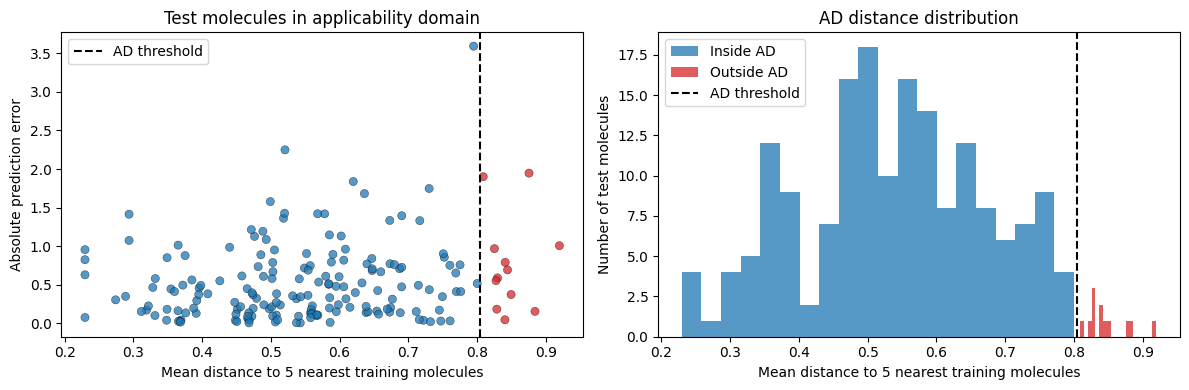

In [17]:
# Plot where the test molecules are in the applicability domain
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

colors = np.where(final_results["in_AD"], "tab:blue", "tab:red")

scatter = axes[0].scatter(
    final_results["knn_mean_distance"],
    final_results["abs_error"],
    c=colors,
    s=35,
    alpha=0.75,
    edgecolor="black",
    linewidth=0.3,
)
axes[0].axvline(ad_threshold, color="black", linestyle="--", label="AD threshold")
axes[0].set_xlabel(f"Mean distance to {k_ad} nearest training molecules")
axes[0].set_ylabel("Absolute prediction error")
axes[0].set_title("Test molecules in applicability domain")
axes[0].legend()

axes[1].hist(
    final_results.loc[final_results["in_AD"], "knn_mean_distance"],
    bins=20,
    alpha=0.75,
    label="Inside AD",
    color="tab:blue",
)
axes[1].hist(
    final_results.loc[~final_results["in_AD"], "knn_mean_distance"],
    bins=20,
    alpha=0.75,
    label="Outside AD",
    color="tab:red",
)
axes[1].axvline(ad_threshold, color="black", linestyle="--", label="AD threshold")
axes[1].set_xlabel(f"Mean distance to {k_ad} nearest training molecules")
axes[1].set_ylabel("Number of test molecules")
axes[1].set_title("AD distance distribution")
axes[1].legend()

plt.tight_layout()
plt.show()

(plots made by chatGPT, but look really good)